# 6주차 실습 — SFT, 선호최적화(DPO), 강화학습(GRPO)

> 주제별 실습 노트북 · 위에서부터 순서대로 실행 · Colab **T4 GPU** 권장 (런타임 → 런타임 유형 변경)

사전학습만 된 언어모델을 "원하는 방식으로 답하는 모델"로 바꾸는 세 가지 학습 신호를, **같은 모델·같은 과제** 위에서 차례로 직접 돌려 봅니다.

| 방법 | 학습 신호 | 필요한 데이터 | 이 노트북 |
|---|---|---|---|
| SFT | 정답 토큰의 likelihood를 올림 | (입력, 정답) | 1~3장 |
| DPO | 두 응답 중 더 나은 쪽의 상대 확률을 올림 | (입력, chosen, rejected) | 4장 |
| RL (GRPO) | 모델이 직접 만든 응답에 점수(reward)를 매겨 강화 | (입력, reward 함수) | 5장 |

```
Pretrained LM ──SFT──▶ SFT 모델 ──┬─ RLHF: 보상모델 학습 + PPO   (이 노트북에서는 생략)
                                  ├─ DPO: 선호 쌍으로 직접 최적화 (4장)
                                  └─ GRPO: 규칙 기반 보상 + 그룹 샘플링 RL (5장)
```

**공통 설정**
- 모델: DistilGPT2 (82M, instruction tuning 없음) — 작아서 T4 한 장으로 SFT·DPO·RL을 모두 직접 학습해 볼 수 있음

## 준비

설치 셀은 처음 한 번만 실행합니다. 같은 런타임에서 다른 버전의 `transformers`를 이미 import했다면 **런타임 → 세션 다시 시작** 후 처음부터 실행하세요.

In [1]:
%pip -q install "transformers==4.57.6" "numpy>=1.26,<2.3" "pandas>=2.2,<3" "matplotlib>=3.8,<3.11"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 41.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.27.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


**코드 읽기**
- `set_seed(SEED)`: `random`·`numpy`·`torch`(CPU/GPU)의 난수 시드를 한 번에 고정합니다. 학습 데이터 샘플링과 생성 샘플링을 재현할 수 있게 하기 위함입니다.
- `torch.cuda.synchronize()`: GPU 연산은 비동기로 실행되므로, 시간을 재기 직전·직후에 동기화해야 실제 연산 시간이 측정됩니다.
- `SMOKE`: 노트북 제작 시 빠른 동작 확인용 스위치입니다. 수업에서는 항상 `False`입니다.

In [2]:
import os, sys, json, math, time, random, hashlib, gc, re, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SMOKE = os.environ.get("LAB_SMOKE_TEST") == "1"   # 제작 검증용 · 수업에서는 False
torch.set_num_threads(min(4, os.cpu_count() or 1))
pd.set_option("display.max_colwidth", 80)

RESULT_DIR = Path("lab_results_week6")
RESULT_DIR.mkdir(exist_ok=True)
ENV = {"python": sys.version.split()[0], "torch": torch.__version__, "device": str(DEVICE),
       "gpu": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else None,
       "seed": SEED, "smoke_test": SMOKE}
display(pd.DataFrame([ENV]))
if DEVICE.type == "cpu":
    print("GPU가 잡히지 않았습니다. 런타임 유형을 T4 GPU로 바꾸는 것을 권장합니다 (CPU는 매우 느림).")

def sync():
    if DEVICE.type == "cuda": torch.cuda.synchronize()

def cleanup():
    gc.collect()
    if DEVICE.type == "cuda": torch.cuda.empty_cache()

def save_json(name, obj):
    (RESULT_DIR / name).write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")

,python,torch,device,gpu,seed,smoke_test
0,3.13.15,2.11.0+cu130,cuda,Tesla T4,42,False


### 모델 불러오기

**코드 읽기**
- `revision=...`: Hugging Face 저장소의 특정 커밋을 고정합니다. 저장소가 나중에 갱신돼도 같은 가중치를 받으므로 결과를 재현할 수 있습니다.
- `tokenizer.pad_token = tokenizer.eos_token`: GPT-2 계열에는 padding 토큰이 따로 없어서, 관례적으로 EOS 토큰(`<|endoftext|>`, id 50256)을 padding에도 씁니다. **같은 id가 두 역할을 하기 때문에** 둘을 구분하는 방법이 중요해집니다.
- `padding_side = "right"`: 학습 때는 짧은 문장의 뒤쪽을 채웁니다. (생성은 이 노트북에서 문장 하나씩 하므로 padding이 필요 없습니다.)
- dropout을 0으로 만드는 이유: 같은 입력에 대한 log-probability가 매번 같아야 DPO·RL 계산(정책 vs 기준 모델 비교)이 깔끔해집니다. SFT·DPO·RL 조건도 동일하게 맞춥니다.
- `use_cache=False`: 학습 시에는 KV cache가 필요 없고 메모리만 차지합니다. 생성할 때는 `generate(..., use_cache=True)`로 따로 켭니다.
- `freeze()`: 기준(reference) 모델처럼 학습하지 않을 모델은 `requires_grad_(False)`로 gradient 계산 대상에서 빼서 메모리와 실수를 줄입니다.

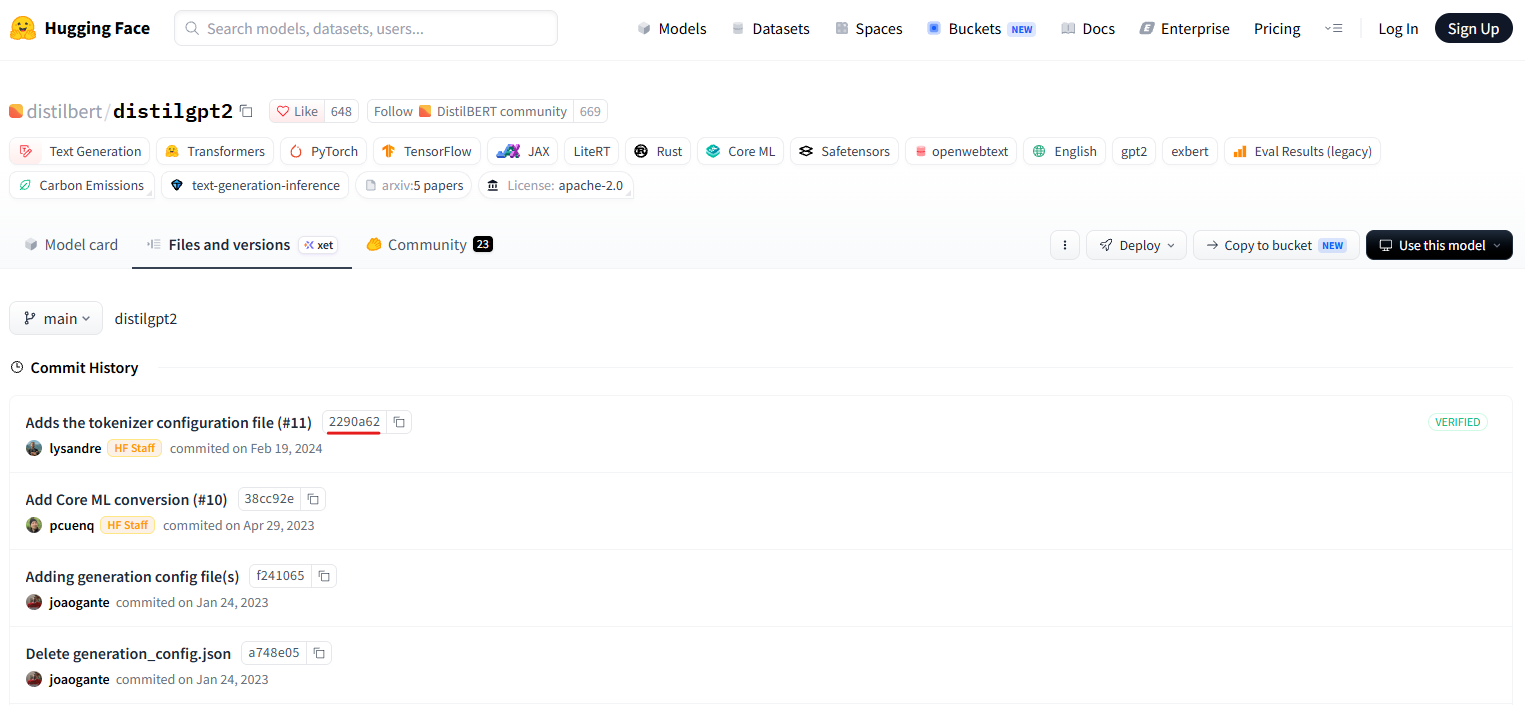

In [3]:
MODEL_ID = "distilbert/distilgpt2"
REVISION = "2290a62682d06624634c1f46a6ad5be0f47f38aa"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=REVISION)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
EOS, PAD = tokenizer.eos_token_id, tokenizer.pad_token_id

def load_base():
    set_seed(SEED)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, revision=REVISION, use_safetensors=True,
        attn_implementation="eager", dtype=torch.float32)
    for module in model.modules():                 # 모든 학습 방식의 dropout 조건 통일
        if isinstance(module, nn.Dropout): module.p = 0.0
    model.config.pad_token_id = PAD
    model.generation_config.pad_token_id = PAD
    model.config.use_cache = False
    return model.to(DEVICE)

def freeze(model):
    model.eval()
    model.requires_grad_(False)
    return model

base_model = freeze(load_base())                  # 학습 전 원본 · 이후 비교 기준으로 계속 사용
MAX_POS = getattr(base_model.config, "n_positions", None) or base_model.config.max_position_embeddings
print("모델:", MODEL_ID, "| 파라미터:", f"{sum(p.numel() for p in base_model.parameters())/1e6:.1f}M",
      "| 최대 문맥 길이:", MAX_POS, "| EOS id:", EOS, "| PAD id:", PAD)
# GPT-2 계열의 경우 n_positions, Llama, Qwen 등의 경우 max_position_embeddings

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

모델: distilbert/distilgpt2 | 파라미터: 81.9M | 최대 문맥 길이: 1024 | EOS id: 50256 | PAD id: 50256


### 데이터 — 세 종류의 입력

| 이름 | 용도 | 특징 |
|---|---|---|
| `train_df` / `val_df` | SFT 학습 / 검증 | **템플릿 기반**: 문장 32개 × 감싸는 문구 3종 × 긴급도 문장 2종 |
| `NATURAL_TEST` | 최종 평가 (학습에 절대 사용 안 함) | **템플릿 밖**의 자연스러운 표현, 긴급도가 문맥으로만 드러남 |
| `ALIGN_PROMPTS` | 4장 DPO·5장 RL의 학습 프롬프트 | `NATURAL_TEST`와 비슷한 스타일이지만 겹치지 않는 문장 |

- 같은 원문 시나리오의 말투 변형은 반드시 같은 split에 넣습니다(`source_id` 기준). 그렇지 않으면 "Please help: X"로 학습하고 "Support request: X"로 검증하는 셈이 되어 검증 점수가 부풀려집니다(데이터 누수).
- `DATA_HASH`: 데이터 전체의 SHA-256 지문입니다. 다른 사람·다른 주차의 결과와 비교할 때 같은 데이터를 썼는지 확인하는 용도입니다.

In [4]:
# 수업용으로 직접 구성한 가상 지원 요청 · 실제 개인정보/외부 데이터 불포함
SCENARIOS = {
 "network":["The lab wifi disconnects", "The wired internet is unavailable", "The router loses its signal",
            "The network connection drops", "The campus wifi has no connection", "The ethernet port is offline",
            "The wireless connection keeps failing", "The internet connection is unstable"],
 "account":["My login password was rejected", "My account is locked", "I cannot sign into my account",
            "The password reset link expired", "My login credentials do not work", "Account authentication fails",
            "The sign in page rejects my password", "My account access is blocked"],
 "hardware":["The monitor has a broken screen", "The keyboard has broken keys", "The mouse button is broken",
             "The laptop battery is damaged", "The printer has a damaged tray", "The desktop fan is broken",
             "The display cable is physically damaged", "The computer power button is broken"],
 "software":["The spreadsheet application crashes", "The editor application will not start", "The browser application freezes",
             "The presentation program crashes", "The drawing application fails to launch", "The code editor freezes",
             "The calendar application crashes on launch", "The document application stops responding"]
}
WRAPPERS = ["{issue}. {urgency}", "Please help: {issue}. {urgency}", "Support request: {issue}. {urgency}"]
URGENCIES = [("This is urgent and blocks today's class.", "high"),
             ("This is routine and can wait until next week.", "normal")]
CATEGORIES = list(SCENARIOS)
PRIORITIES = ["high", "normal"]
def fmt_answer(category, priority): return f"category={category}; priority={priority}"
CANDIDATES = [fmt_answer(c, p) for c in CATEGORIES for p in PRIORITIES]   # 가능한 정답 8개

def make_records():
    rows = []
    for category, issues in SCENARIOS.items():
        for i, issue in enumerate(issues):
            split = "train" if i < 6 else ("validation" if i == 6 else "test")
            for urgency, priority in URGENCIES:
                for j, wrapper in enumerate(WRAPPERS):
                    rows.append({"id": f"{category}-{i}-{priority}-{j}", "source_id": f"{category}-{i}",
                                 "split": split, "text": wrapper.format(issue=issue, urgency=urgency),
                                 "category": category, "priority": priority,
                                 "answer": fmt_answer(category, priority)})
    return pd.DataFrame(rows)

# 템플릿 밖 자연스러운 표현 · 최종 평가 전용 (category 4 × priority 2 × 2문장)
NATURAL_TEST = pd.DataFrame([
 ("Our seminar room has had no internet since this morning and my talk starts in ten minutes.", "network", "high"),
 ("Zoom keeps dropping because the connection cuts out, and I'm presenting right now.", "network", "high"),
 ("Wi-Fi in the library is a bit slow lately; no rush, whenever you get a chance.", "network", "normal"),
 ("The network in room 302 is flaky sometimes. Not a big deal, just letting you know.", "network", "normal"),
 ("I got locked out of the portal and the assignment deadline is in an hour!", "account", "high"),
 ("Two-factor codes aren't arriving and I can't log in to submit my exam.", "account", "high"),
 ("Could someone reset my password at some point? I don't need it until next month.", "account", "normal"),
 ("My username shows an old email address; please fix it when convenient.", "account", "normal"),
 ("The projector bulb just died and the lecture has already started.", "hardware", "high"),
 ("My laptop won't power on at all and I need it for the exam this afternoon.", "hardware", "high"),
 ("The spare mouse in cabinet B has a sticky wheel, no hurry.", "hardware", "normal"),
 ("The second monitor flickers a little; it's fine to look at it after the holidays.", "hardware", "normal"),
 ("Excel freezes every time I open the grading sheet, and grades are due today.", "software", "high"),
 ("The Python IDE crashes on startup and my students are waiting for the demo.", "software", "high"),
 ("The PDF viewer shows a minor rendering glitch; low priority.", "software", "normal"),
 ("Can you update the slide software sometime? The current version still works.", "software", "normal"),
], columns=["text", "category", "priority"])

# 4~5장 정렬 학습용 프롬프트 · NATURAL_TEST와 겹치지 않음
ALIGN_PROMPTS = pd.DataFrame([
 ("The VPN won't connect and I have to upload results before noon.", "network", "high"),
 ("Nobody in the lab can reach the internet and the class demo is starting.", "network", "high"),
 ("Ethernet in my office occasionally drops for a second, nothing urgent.", "network", "normal"),
 ("Wi-Fi signal is weak near the window, maybe check it next month.", "network", "normal"),
 ("My email account was suspended and I must reply to the dean today.", "account", "high"),
 ("The system says my password expired and I can't open the exam page now.", "account", "high"),
 ("I'd like to change my login name eventually.", "account", "normal"),
 ("Please merge my two accounts when you have time.", "account", "normal"),
 ("The lab PC smells like burning and shut down during the experiment.", "hardware", "high"),
 ("The printer jammed and the exam papers must be printed in 20 minutes.", "hardware", "high"),
 ("A key on the spare keyboard is slightly loose, no rush.", "hardware", "normal"),
 ("My webcam image is a little blurry; it's not urgent.", "hardware", "normal"),
 ("The statistics package crashes whenever I run the final analysis due tonight.", "software", "high"),
 ("The LMS page throws errors and students can't submit their quiz right now.", "software", "high"),
 ("Could you install a newer browser version sometime?", "software", "normal"),
 ("The music player app shows an odd icon; look at it whenever.", "software", "normal"),
], columns=["text", "category", "priority"])
for frame in (NATURAL_TEST, ALIGN_PROMPTS):
    frame["answer"] = [fmt_answer(c, p) for c, p in zip(frame.category, frame.priority)]
assert set(NATURAL_TEST.text).isdisjoint(ALIGN_PROMPTS.text)

data = make_records()
def split_data(data):
    return (data[data.split == "train"].reset_index(drop=True),
            data[data.split == "validation"].reset_index(drop=True),
            data[data.split == "test"].reset_index(drop=True))
train_df, val_df, test_df = split_data(data)
for a, b in [(train_df, val_df), (train_df, test_df), (val_df, test_df)]:
    assert set(a.source_id).isdisjoint(b.source_id), "같은 원문이 서로 다른 split에 있음"
DATA_HASH = hashlib.sha256(data.to_json(orient="records").encode()).hexdigest()
print("템플릿 데이터:", data.groupby("split").size().to_dict(), "| 자연 표현 평가:", len(NATURAL_TEST),
      "| 정렬 학습 프롬프트:", len(ALIGN_PROMPTS), "| 지문:", DATA_HASH[:12])
display(train_df[["text", "answer"]].head(3))
display(NATURAL_TEST.head(3))

템플릿 데이터: {'test': 24, 'train': 144, 'validation': 24} | 자연 표현 평가: 16 | 정렬 학습 프롬프트: 16 | 지문: 387a20a315ef


,text,answer
0,The lab wifi disconnects. This is urgent and blocks today's class.,category=network; priority=high
1,Please help: The lab wifi disconnects. This is urgent and blocks today's class.,category=network; priority=high
2,Support request: The lab wifi disconnects. This is urgent and blocks today's...,category=network; priority=high


,text,category,priority,answer
0,Our seminar room has had no internet since this morning and my talk starts i...,network,high,category=network; priority=high
1,"Zoom keeps dropping because the connection cuts out, and I'm presenting righ...",network,high,category=network; priority=high
2,"Wi-Fi in the library is a bit slow lately; no rush, whenever you get a chance.",network,normal,category=network; priority=normal


---
##  1장. SFT의 loss는 어느 토큰에 거는가

사전학습 loss는 모든 토큰에 대해 $\mathcal{L} = -\sum_t \log p_\theta(x_t \mid x_{<t})$ 입니다. SFT에서는 입력을 (프롬프트, 응답)으로 나누고 **응답 토큰에만** loss를 겁니다.

$$\mathcal{L}_{\text{SFT}} = -\sum_{t \in \text{응답}} \log p_\theta(y_t \mid \text{프롬프트}, y_{<t})$$

- 프롬프트는 사용자가 주는 것이므로 모델이 "생성"하도록 배울 필요가 없습니다.
- 프롬프트가 응답보다 훨씬 길면, 프롬프트까지 학습할 경우 gradient 대부분이 이미 아는 지시문을 외우는 데 쓰입니다.

**코드 읽기**
- **`-100`**: PyTorch `CrossEntropyLoss`의 기본 `ignore_index`입니다. label이 -100인 위치는 loss 평균과 gradient 계산에서 완전히 빠집니다. 그래서 "loss를 안 건다" = "label을 -100으로 둔다"입니다.
- **Hugging Face가 내부에서 한 칸 shift**: `model(input_ids, labels=labels)`를 호출하면 내부에서 `logits[:, :-1]`과 `labels[:, 1:]`를 짝지어 loss를 계산합니다. 즉 위치 $t$의 출력이 위치 $t+1$의 토큰을 맞히도록 이미 처리되어 있으므로, **labels는 input_ids와 같은 위치에 그대로** 넣습니다. 직접 한 번 더 shift하면 두 칸 뒤 토큰을 예측하도록 잘못 학습됩니다.
- **EOS vs padding**: 정답 뒤에 EOS를 붙여 학습해야 모델이 "어디서 멈출지"를 배웁니다. 그런데 GPT-2에서는 PAD id = EOS id이므로, `labels[input_ids == eos] = -100` 같은 **id 기준 마스킹을 쓰면 진짜 EOS까지 지워집니다.** padding은 id가 아니라 **위치**(collate에서 덧붙인 자리, `attention_mask == 0`)로 구분해야 합니다.
- **`collate`**: 길이가 다른 문장들을 한 배치로 묶기 위해 뒤쪽을 PAD로 채우고, 채운 자리는 `attention_mask=0`, `labels=-100`으로 둡니다.

In [5]:
MAX_LENGTH = 128
MASK_PROMPT = True     # ▶ 직접 해보기: False → 프롬프트 토큰에도 loss를 건다
DOUBLE_SHIFT = False   # ▶ 직접 해보기: True → labels를 직접 한 칸 더 shift하는 흔한 실수를 재현

def make_prompt(text):
    return ("Classify the support request. Categories: network, account, hardware, software. "
            "Priorities: high, normal.\nRequest: " + text + "\nAnswer:")

def encode_pair(prompt, answer, mask_prompt=True):
    # 프롬프트와 응답을 따로 토큰화한 뒤 이어 붙여야 경계 위치(n_prompt)를 정확히 알 수 있음
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    answer_ids = tokenizer.encode(" " + answer, add_special_tokens=False) + [EOS]   # 진짜 EOS는 학습 대상
    ids = prompt_ids + answer_ids
    labels = ([-100] * len(prompt_ids) if mask_prompt else list(prompt_ids)) + answer_ids
    return ids, labels, len(prompt_ids)

def encode_row(row):
    ids, labels, _ = encode_pair(make_prompt(row["text"]), row["answer"], MASK_PROMPT)
    assert len(ids) <= MAX_LENGTH, f"길이 {len(ids)} > MAX_LENGTH {MAX_LENGTH}: 입력 문장 또는 MAX_LENGTH 확인"
    if DOUBLE_SHIFT:
        labels = labels[1:] + [-100]          # 잘못된 구현: 모델 내부 shift와 겹쳐 두 칸 뒤를 예측하게 됨
    return {"input_ids": ids, "labels": labels}

def collate(items):
    length = max(len(x["input_ids"]) for x in items)
    ids, masks, labels = [], [], []
    for x in items:
        n = len(x["input_ids"]); pad = length - n
        ids.append(x["input_ids"] + [PAD] * pad)
        masks.append([1] * n + [0] * pad)          # padding 위치는 attention에서 제외
        labels.append(x["labels"] + [-100] * pad)  # padding 위치는 loss에서 제외 (id가 아니라 위치 기준)
    return {k: torch.tensor(v, device=DEVICE) for k, v in
            {"input_ids": ids, "attention_mask": masks, "labels": labels}.items()}

train_items = [encode_row(r) for r in train_df.to_dict("records")]
val_items = [encode_row(r) for r in val_df.to_dict("records")]
print(f"MASK_PROMPT={MASK_PROMPT}, DOUBLE_SHIFT={DOUBLE_SHIFT} | train {len(train_items)}개, validation {len(val_items)}개")

MASK_PROMPT=True, DOUBLE_SHIFT=False | train 144개, validation 24개


### 1-1. 토큰별 label 확인

아래 표의 마지막 열은 "이 위치의 출력(logit)이 실제로 맞히도록 학습되는 토큰"입니다. 모델 내부 shift 때문에 **같은 행의 label이 아니라 다음 행의 label**이 그 위치의 목표가 됩니다. `Answer` 토큰의 출력이 정답의 첫 토큰을 맞혀야 한다는 점을 확인하세요.

In [6]:
def token_table(item, last=None):
    toks = tokenizer.convert_ids_to_tokens(item["input_ids"])
    lab = item["labels"]
    def name(i): return tokenizer.convert_ids_to_tokens(i) if i != -100 else "·"
    target = [name(lab[t + 1]) if t + 1 < len(lab) and lab[t + 1] != -100 else "(loss 없음)" for t in range(len(lab))]
    table = pd.DataFrame({"input_token": toks, "label": lab, "label_token": [name(l) for l in lab],
                          "이 위치 출력이 맞혀야 할 토큰": target})
    return table.tail(last) if last else table

display(token_table(train_items[0], last=14))

if MASK_PROMPT and not DOUBLE_SHIFT:
    probe = train_items[0]
    n_prompt = encode_pair(make_prompt(train_df.iloc[0].text), train_df.iloc[0].answer)[2]
    assert all(x == -100 for x in probe["labels"][:n_prompt]), "프롬프트 위치에 loss가 걸려 있습니다"
    assert probe["labels"][n_prompt:] == probe["input_ids"][n_prompt:], "응답 위치 label이 input_ids와 달라야 할 이유가 없습니다"
    assert probe["labels"][-1] == EOS, "마지막 EOS가 학습 대상이 아닙니다 → 모델이 멈추는 법을 못 배움"
    print("확인 완료: 프롬프트 = -100, 응답 + EOS = 학습 대상")

,input_token,label,label_token,이 위치 출력이 맞혀야 할 토큰
38,'s,-100,·,(loss 없음)
39,Ġclass,-100,·,(loss 없음)
40,.,-100,·,(loss 없음)
41,Ċ,-100,·,(loss 없음)
42,Answer,-100,·,(loss 없음)
43,:,-100,·,Ġcategory
44,Ġcategory,6536,Ġcategory,=
45,=,28,=,network
46,network,27349,network,;
47,;,26,;,Ġpriority


확인 완료: 프롬프트 = -100, 응답 + EOS = 학습 대상


### 1-2. EOS와 padding — 같은 id, 다른 처리

길이가 다른 두 문장을 한 배치로 묶어, **짧은 문장**의 끝부분을 봅니다. `input_id`가 모두 50256(EOS=PAD)인 위치들 중 **첫 번째(진짜 EOS)만 label이 살아 있어야** 합니다.

In [7]:
lengths = [len(x["input_ids"]) for x in train_items]
short_i, long_i = int(np.argmin(lengths)), int(np.argmax(lengths))
batch = collate([train_items[short_i], train_items[long_i]])
n_short = lengths[short_i]
view = pd.DataFrame({"pos": range(batch["input_ids"].shape[1]),
                     "input_id": batch["input_ids"][0].tolist(),
                     "attention_mask": batch["attention_mask"][0].tolist(),
                     "label": batch["labels"][0].tolist()}).iloc[n_short - 4: n_short + 3]
view["설명"] = ["응답" if p < n_short - 1 else ("진짜 EOS (학습)" if p == n_short - 1 else "padding (무시)") for p in view.pos]
display(view)
assert torch.all(batch["labels"][batch["attention_mask"] == 0] == -100), "padding 위치에 loss가 걸려 있습니다"

,pos,input_id,attention_mask,label,설명
46,46,8475,1,8475,응답
47,47,28,1,28,응답
48,48,8929,1,8929,응답
49,49,50256,1,50256,진짜 EOS (학습)
50,50,50256,0,-100,padding (무시)
51,51,50256,0,-100,padding (무시)
52,52,50256,0,-100,padding (무시)


**▶ 직접 해보기** (1장 첫 코드 셀의 스위치를 바꾸고 1장~2장을 다시 실행)
- `DOUBLE_SHIFT=True`: 1-1 표의 마지막 열이 어떻게 바뀌는지 보고, 2장 SFT 후 생성 결과가 어떻게 망가지는지 확인
- `MASK_PROMPT=False`: 2장의 학습 loss 수치와 정확도가 어떻게 달라지는지 확인 (loss 수치를 그대로 비교해도 되는가?)

**▶ 생각해 볼 점**
- 멀티턴 대화 데이터라면 어떤 토큰에 loss를 걸어야 할까? (이전 턴의 assistant 응답은?)
- 학습 데이터에서 EOS를 아예 빼면 추론 시 어떤 현상이 생길까?

---
## 2장. 예시 제공(few-shot) vs 학습(SFT)

| | few-shot (in-context learning) | SFT |
|---|---|---|
| 파라미터 | 고정 | 업데이트 |
| 비용이 드는 시점 | **추론할 때마다** (예시만큼 입력이 길어짐) | **학습 1회** (이후 추론은 짧은 입력) |
| 필요 조건 | 모델이 예시로부터 패턴을 읽어낼 능력 | 정답 데이터 |

### 두 가지 평가 방식
1. **자유 생성 exact match**: greedy로 생성한 문자열이 정답과 정확히 같은가 → *형식 + 내용*을 함께 봄
2. **후보 채점 (constrained scoring)**: 가능한 정답 8개 각각에 대해 $\log p(\text{후보} \mid \text{프롬프트})$를 계산하고 가장 높은 후보를 선택 → *형식과 무관하게 내용만* 봄

작은 모델은 형식을 못 맞춰서 자유 생성 점수가 0이 되기 쉽습니다. 이때 0점이 "아무것도 모른다"는 뜻인지, "알지만 형식을 못 맞춘다"는 뜻인지 구분하려면 후보 채점이 필요합니다. (무작위로 고르면 1/8 = 12.5%)

**코드 읽기**
- **`completion_logprobs`**: (프롬프트, 응답) 쌍마다 응답 토큰들의 log-probability 합 $\sum_t \log p(y_t \mid \cdot)$을 구합니다. 4장 DPO에서도 그대로 다시 씁니다.
  - `logits[:, :-1]`와 `labels[:, 1:]`: 1장의 shift를 여기서는 직접 맞춥니다(모델 내부 loss를 쓰지 않으므로).
  - `log_softmax(-1).gather(-1, targets)`: 어휘 전체(50257개)의 log-확률 중 **실제 정답 토큰 위치의 값만** 뽑습니다. `clamp(min=0)`은 -100을 인덱스로 쓸 수 없어 임시로 0으로 바꾸는 것이며, 그 위치는 곧바로 mask로 지워집니다.
- **`@torch.no_grad()`**: 평가 함수에서 계산 그래프를 만들지 않아 메모리와 시간을 절약합니다.
- **`model.generate(do_sample=False)`**: greedy decoding (매 스텝 가장 확률이 높은 토큰). `max_new_tokens`는 최대 생성 길이, `eos_token_id`가 나오면 멈춥니다.
- **`.split("\n")[0]`**: few-shot 프롬프트를 받은 모델은 EOS 대신 줄바꿈 후 다음 예시를 계속 써 내려가는 경향이 있습니다. 공정한 비교를 위해 모든 조건에서 첫 줄만 답으로 씁니다.

In [8]:
ANSWER_RE = re.compile(r"category=(network|account|hardware|software); priority=(high|normal)")
def parse_answer(text):
    m = ANSWER_RE.fullmatch(text.strip())
    return (m.group(1), m.group(2)) if m else None

def completion_logprobs(model, prompts, completions):
    # 반환: 각 쌍의 log p(completion + EOS | prompt) · gradient 흐름 유지 (DPO에서 재사용)
    items = []
    for p, c in zip(prompts, completions):
        ids, labels, _ = encode_pair(p, c, mask_prompt=True)
        items.append({"input_ids": ids, "labels": labels})
    b = collate(items)
    logits = model(input_ids=b["input_ids"], attention_mask=b["attention_mask"]).logits
    logp = logits[:, :-1].float().log_softmax(-1)          # 위치 t의 출력 → 토큰 t+1 예측
    targets = b["labels"][:, 1:]
    mask = targets != -100
    token_logp = logp.gather(-1, targets.clamp(min=0).unsqueeze(-1)).squeeze(-1)
    return (token_logp * mask).sum(-1)

@torch.no_grad()
def candidate_scores(model, prompts, batch_size=16):
    # (프롬프트 수, 8) 행렬: 각 후보 정답의 log-probability
    model.eval()
    pairs = [(p, c) for p in prompts for c in CANDIDATES]
    out = []
    for i in range(0, len(pairs), batch_size):
        chunk = pairs[i:i + batch_size]
        out.append(completion_logprobs(model, [p for p, _ in chunk], [c for _, c in chunk]).cpu())
    return torch.cat(out).view(len(prompts), len(CANDIDATES))

@torch.no_grad()
def greedy_answer(model, prompt, max_new_tokens=16):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    assert inputs.input_ids.shape[1] + max_new_tokens <= MAX_POS, "프롬프트가 모델 최대 길이를 넘습니다"
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, use_cache=True,
                         pad_token_id=PAD, eos_token_id=EOS)
    text = tokenizer.decode(out[0, inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return text.split("\n")[0].strip()

# few-shot 예시는 train에서만 선택 (평가 문장 유출 방지) · 서로 다른 category/priority 조합
DEMO_KEYS = [("network", "high"), ("account", "normal"), ("hardware", "normal"), ("software", "high")]
DEMOS = [train_df[(train_df.category == c) & (train_df.priority == p)].iloc[0] for c, p in DEMO_KEYS]
def few_shot_prompt(text, shots):
    prefix = "".join(make_prompt(d.text) + " " + d.answer + "\n\n" for d in DEMOS[:shots])
    return prefix + make_prompt(text)

def evaluate(model, frame, shots=0, condition=""):
    prompts = [few_shot_prompt(t, shots) for t in frame.text]
    scores = candidate_scores(model, prompts)
    rows = []
    for k, r in enumerate(frame.to_dict("records")):
        pred = greedy_answer(model, prompts[k])
        parsed = parse_answer(pred)
        best = CANDIDATES[int(scores[k].argmax())]
        rows.append({"condition": condition, "text": r["text"], "expected": r["answer"], "generated": pred,
                     "gen_exact": pred == r["answer"], "gen_format_ok": parsed is not None,
                     "scored_pred": best, "scored_correct": best == r["answer"],
                     "scored_cat_ok": parse_answer(best)[0] == r["category"],
                     "scored_prio_ok": parse_answer(best)[1] == r["priority"],
                     "input_tokens": len(tokenizer.encode(prompts[k]))})
    return pd.DataFrame(rows)

def summarize(df):
    return {"생성 exact": df.gen_exact.mean(), "생성 형식 준수": df.gen_format_ok.mean(),
            "후보채점 정확도": df.scored_correct.mean(), "category 정확도": df.scored_cat_ok.mean(),
            "priority 정확도": df.scored_prio_ok.mean(), "평균 입력 토큰": df.input_tokens.mean()}

### 2-1. 학습 전 모델: zero-shot / 2-shot / 4-shot

템플릿 검증셋(`val`)과 자연 표현 평가셋(`natural`) 두 곳에서 봅니다. 몇 분 걸릴 수 있습니다.

In [9]:
results = {}     # (조건, 평가셋) → 행 단위 결과 · 장 끝 요약에서 재사용
for shots in [0, 2, 4]:
    for set_name, frame in [("val", val_df), ("natural", NATURAL_TEST)]:
        results[(f"base {shots}-shot", set_name)] = evaluate(base_model, frame, shots, f"base {shots}-shot")

def summary_table(keys):
    rows = [{"조건": c, "평가셋": s, **summarize(results[(c, s)])} for c, s in keys]
    return pd.DataFrame(rows).set_index(["조건", "평가셋"]).round(3)

display(summary_table([(f"base {k}-shot", s) for k in [0, 2, 4] for s in ["val", "natural"]]))
display(results[("base 4-shot", "natural")][["text", "expected", "generated", "scored_pred"]].head(4))

생성 exact  생성 형식 준수  후보채점 정확도  category 정확도  priority 정확도  \
조건          평가셋                                                                 
base 0-shot val         0.000     0.000     0.125         0.250         0.500   
            natural     0.000     0.000     0.188         0.375         0.500   
base 2-shot val         0.250     1.000     0.250         0.375         0.500   
            natural     0.188     1.000     0.188         0.438         0.562   
base 4-shot val         0.125     1.000     0.125         0.250         0.500   
            natural     0.188     0.938     0.250         0.500         0.500   

                     평균 입력 토큰  
조건          평가셋                
base 0-shot val        47.500  
            natural    45.312  
base 2-shot val       154.500  
            natural   152.312  
base 4-shot val       262.500  
            natural   260.312

,text,expected,generated,scored_pred
0,Our seminar room has had no internet since this morning and my talk starts i...,category=network; priority=high,category=software; priority=normal,category=hardware; priority=normal
1,"Zoom keeps dropping because the connection cuts out, and I'm presenting righ...",category=network; priority=high,category=hardware; priority=normal,category=hardware; priority=normal
2,"Wi-Fi in the library is a bit slow lately; no rush, whenever you get a chance.",category=network; priority=normal,category=hardware; priority=normal,category=hardware; priority=normal
3,"The network in room 302 is flaky sometimes. Not a big deal, just letting you...",category=network; priority=normal,category=hardware; priority=normal,category=hardware; priority=normal


### 2-2. SFT 학습

**코드 읽기**
- **gradient accumulation** (`ACCUM_STEPS`): 작은 배치 여러 개의 gradient를 더한 뒤 한 번만 `optimizer.step()` 합니다. 유효 배치 크기 = `BATCH_SIZE × ACCUM_STEPS`. loss를 `ACCUM_STEPS`로 나눠야 큰 배치 하나의 평균 loss와 같은 크기의 gradient가 됩니다.
- **`clip_grad_norm_(params, 1.0)`**: 전체 gradient 벡터의 L2 norm이 1을 넘으면 1로 축소합니다. 학습 초반 loss가 클 때 한 번에 크게 튀는 업데이트를 막습니다.
- **`zero_grad(set_to_none=True)`**: gradient를 0으로 채우는 대신 `None`으로 비워 메모리 쓰기를 줄입니다.
- **`rng.integers(...)`**: 매 스텝 train에서 복원추출로 배치를 뽑습니다(epoch 개념 없이 step 수로 학습량 통제).
- **`torch.cuda.max_memory_allocated()`**: 학습 중 최대 GPU 메모리 사용량(모델 + gradient + AdamW 상태 + activation)입니다. AdamW는 파라미터마다 상태 2개(1차·2차 모멘트)를 저장하므로 모델 크기의 약 2배 메모리를 추가로 씁니다.
- 학습 도중 `EVAL_EVERY` 스텝마다 validation NLL과 자연 표현 정확도를 기록합니다(3장에서 사용).

In [10]:
# 학습 설정 변경은 이 셀에서만 · 7주차와 비교하려면 설정을 그대로 유지
STEPS = 3 if SMOKE else (60 if DEVICE.type == "cuda" else 8)
BATCH_SIZE = 2 if SMOKE else (4 if DEVICE.type == "cuda" else 1)
ACCUM_STEPS = 1 if SMOKE else 2
LEARNING_RATE = 1e-4
EVAL_EVERY = 1 if SMOKE else 10
TRAIN_CONFIG = dict(steps=STEPS, batch_size=BATCH_SIZE, accum_steps=ACCUM_STEPS, lr=LEARNING_RATE,
                    max_length=MAX_LENGTH, seed=SEED, dropout=0.0, mask_prompt=MASK_PROMPT, double_shift=DOUBLE_SHIFT)

@torch.no_grad()
def answer_nll(model, items):
    # 응답 토큰당 평균 NLL (teacher forcing: 정답 앞부분을 입력으로 넣어 준 상태의 예측)
    model.eval(); total, count = 0.0, 0
    for start in range(0, len(items), 8):
        b = collate(items[start:start + 8])
        n = int((b["labels"][:, 1:] != -100).sum())
        total += float(model(**b).loss) * n; count += n
    return total / count

@torch.no_grad()
def natural_checkpoint(model):
    scores = candidate_scores(model, [make_prompt(t) for t in NATURAL_TEST.text])
    scored = np.mean([CANDIDATES[int(s.argmax())] == a for s, a in zip(scores, NATURAL_TEST.answer)])
    gen = np.mean([greedy_answer(model, make_prompt(t)) == a for t, a in zip(NATURAL_TEST.text, NATURAL_TEST.answer)])
    return scored, gen

def train_sft(model, label="full_sft"):
    set_seed(SEED); rng = np.random.default_rng(SEED)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=LEARNING_RATE, weight_decay=0.0)
    cleanup(); sync()
    if DEVICE.type == "cuda": torch.cuda.reset_peak_memory_stats()
    history, checkpoints, train_seconds = [], [], 0.0
    def checkpoint(step):
        s, g = natural_checkpoint(model)
        checkpoints.append({"step": step, "val_nll": answer_nll(model, val_items), "natural_scored_acc": s, "natural_gen_exact": g})
    checkpoint(0)
    for step in range(STEPS):
        sync(); t0 = time.perf_counter()
        model.train(); optimizer.zero_grad(set_to_none=True); loss_sum = 0.0
        for _ in range(ACCUM_STEPS):
            idx = rng.integers(0, len(train_items), size=BATCH_SIZE)
            loss = model(**collate([train_items[int(i)] for i in idx])).loss
            assert torch.isfinite(loss), "loss가 NaN/inf입니다. learning rate나 label 구성을 확인하세요"
            (loss / ACCUM_STEPS).backward()
            loss_sum += float(loss.detach()) / ACCUM_STEPS
        nn.utils.clip_grad_norm_(trainable, 1.0)
        optimizer.step()
        sync(); train_seconds += time.perf_counter() - t0      # 평가 시간은 학습 비용에서 제외
        history.append({"step": step + 1, "train_loss": loss_sum})
        if (step + 1) % EVAL_EVERY == 0 or step + 1 == STEPS:
            checkpoint(step + 1)
            c = checkpoints[-1]
            print(f"{label} {step+1:>3}/{STEPS}  train_loss={loss_sum:.4f}  val_nll={c['val_nll']:.4f}  "
                  f"natural 후보채점={c['natural_scored_acc']:.2f}  natural 생성={c['natural_gen_exact']:.2f}")
    stats = {"method": label, "train_seconds": round(train_seconds, 2),
             "trainable_parameters": sum(p.numel() for p in trainable),
             "peak_allocated_MiB": torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == "cuda" else None}
    del optimizer; cleanup()
    return pd.DataFrame(history), pd.DataFrame(checkpoints).drop_duplicates("step"), stats

sft_model = load_base()
sft_history, sft_checkpoints, sft_stats = train_sft(sft_model)
freeze(sft_model)
display(pd.DataFrame([sft_stats]))

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


full_sft  10/60  train_loss=0.0180  val_nll=0.1576  natural 후보채점=0.44  natural 생성=0.44
full_sft  20/60  train_loss=0.0010  val_nll=0.0390  natural 후보채점=0.44  natural 생성=0.44
full_sft  30/60  train_loss=0.0008  val_nll=0.2459  natural 후보채점=0.38  natural 생성=0.38
full_sft  40/60  train_loss=0.0001  val_nll=0.0226  natural 후보채점=0.44  natural 생성=0.44
full_sft  50/60  train_loss=0.0000  val_nll=0.0043  natural 후보채점=0.44  natural 생성=0.44
full_sft  60/60  train_loss=0.0000  val_nll=0.0020  natural 후보채점=0.44  natural 생성=0.44


,method,train_seconds,trainable_parameters,peak_allocated_MiB
0,full_sft,7.26,81912576,2136.776367


In [11]:
for set_name, frame in [("val", val_df), ("natural", NATURAL_TEST)]:
    results[("SFT 0-shot", set_name)] = evaluate(sft_model, frame, 0, "SFT 0-shot")
display(summary_table([(c, s) for s in ["val", "natural"] for c in ["base 0-shot", "base 4-shot", "SFT 0-shot"]]))
print(f"SFT 학습 비용: {sft_stats['train_seconds']}초 (1회)  |  few-shot 추가 비용: 매 요청마다 입력 토큰 증가")

save_json("sft_summary.json", {"signature": {"model_id": MODEL_ID, "revision": REVISION, "data_hash": DATA_HASH,
                                              "train_config": TRAIN_CONFIG, "environment": ENV},
                                "stats": sft_stats, "checkpoints": sft_checkpoints.to_dict("records")})

,,생성 exact,생성 형식 준수,후보채점 정확도,category 정확도,priority 정확도,평균 입력 토큰
조건,평가셋,,,,,,
base 0-shot,val,0.000,0.000,0.125,0.250,0.5,47.500
base 4-shot,val,0.125,1.000,0.125,0.250,0.5,262.500
SFT 0-shot,val,1.000,1.000,1.000,1.000,1.0,47.500
base 0-shot,natural,0.000,0.000,0.188,0.375,0.5,45.312
base 4-shot,natural,0.188,0.938,0.250,0.500,0.5,260.312
SFT 0-shot,natural,0.438,1.000,0.438,0.812,0.5,45.312


SFT 학습 비용: 7.26초 (1회)  |  few-shot 추가 비용: 매 요청마다 입력 토큰 증가


**▶ 직접 해보기**
- `LEARNING_RATE`를 `1e-5`나 `5e-4`로 바꿔 SFT 다시 실행: val과 natural 결과가 같은 방향으로 움직이는가?
- `DEMO_KEYS` 순서를 바꾸거나 예시를 자연 표현 문장으로 바꿔 few-shot 다시 실행: 예시의 **스타일**이 결과에 영향을 주는가?

**▶ 생각해 볼 점**
- 생성 exact와 후보채점 정확도가 크게 다른 조건이 있다면, 그 차이는 무엇을 의미하는가?
- 하루 100만 건을 처리하는 서비스라면 few-shot과 SFT 중 어느 쪽의 총비용이 더 작을까? 입력 토큰 수를 근거로 대략 따져 보자.
- 이 모델(82M)에서 few-shot이 잘 안 된다면, 그건 few-shot이라는 방법의 한계일까, 모델 규모의 한계일까?

---
## 3장. 학습 loss가 0이면 다 맞히는가?

2장 학습 중 기록한 값을 그려 봅니다. 템플릿 데이터의 loss·NLL이 0 근처로 떨어지는 동안, **템플릿 밖** 자연 표현 정확도는 어떻게 움직이는지 확인하세요.

- `val_nll`은 **teacher forcing** 값입니다: 정답의 앞 토큰들을 입력으로 넣어 준 상태에서 다음 토큰을 맞히는 능력이라, 모델이 스스로 생성할 때의 성공과는 다를 수 있습니다.
- y축 로그 스케일(`set_yscale("log")`)은 0에 가까운 loss 변화를 보기 위함입니다.

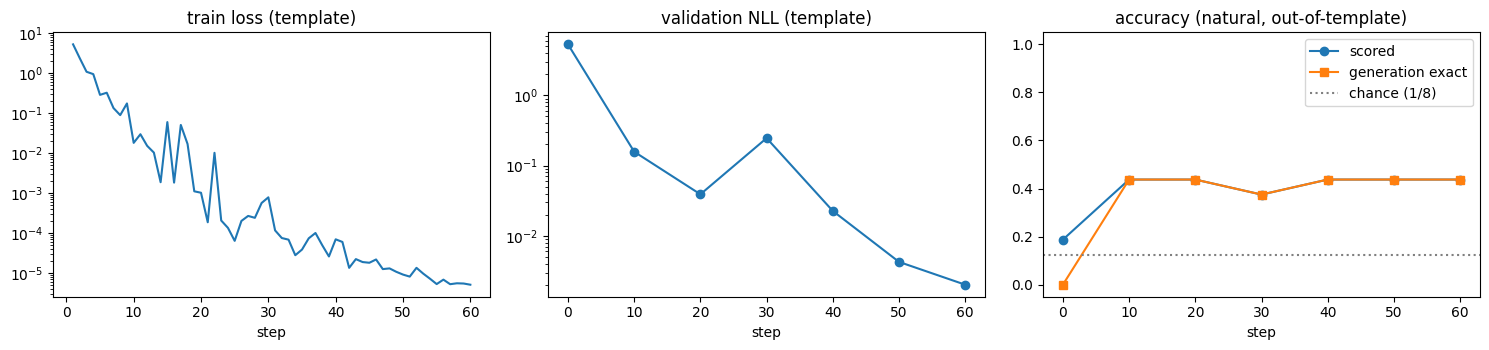

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(sft_history.step, sft_history.train_loss); axes[0].set_yscale("log")
axes[0].set_title("train loss (template)"); axes[0].set_xlabel("step")
axes[1].plot(sft_checkpoints.step, sft_checkpoints.val_nll, marker="o"); axes[1].set_yscale("log")
axes[1].set_title("validation NLL (template)"); axes[1].set_xlabel("step")
axes[2].plot(sft_checkpoints.step, sft_checkpoints.natural_scored_acc, marker="o", label="scored")
axes[2].plot(sft_checkpoints.step, sft_checkpoints.natural_gen_exact, marker="s", label="generation exact")
axes[2].axhline(1/8, ls=":", c="gray", label="chance (1/8)")
axes[2].set_ylim(-0.05, 1.05); axes[2].set_title("accuracy (natural, out-of-template)")
axes[2].set_xlabel("step"); axes[2].legend()
plt.tight_layout(); plt.show()

### 3-1. 어디서 틀리는가 — 오류 유형 분석

Natural 표현 평가셋에서 SFT 모델의 생성 결과를 **형식 오류 / category 오류 / priority 오류**로 나눕니다.

In [13]:
def error_type(row):
    p = parse_answer(row["generated"])
    if p is None: return "형식 오류"
    exp = parse_answer(row["expected"])
    wrong = [name for name, a, b in [("category", p[0], exp[0]), ("priority", p[1], exp[1])] if a != b]
    return "정답" if not wrong else " + ".join(wrong) + " 오류"

nat = results[("SFT 0-shot", "natural")].copy()
nat["오류 유형"] = nat.apply(error_type, axis=1)
display(nat["오류 유형"].value_counts().to_frame("개수"))
display(nat[nat["오류 유형"] != "정답"][["text", "expected", "generated", "오류 유형"]])

,개수
오류 유형,
정답,7
priority 오류,6
category + priority 오류,2
category 오류,1


,text,expected,generated,오류 유형
2,"Wi-Fi in the library is a bit slow lately; no rush, whenever you get a chance.",category=network; priority=normal,category=network; priority=high,priority 오류
3,"The network in room 302 is flaky sometimes. Not a big deal, just letting you...",category=network; priority=normal,category=account; priority=high,category + priority 오류
6,Could someone reset my password at some point? I don't need it until next mo...,category=account; priority=normal,category=account; priority=high,priority 오류
7,My username shows an old email address; please fix it when convenient.,category=account; priority=normal,category=account; priority=high,priority 오류
10,"The spare mouse in cabinet B has a sticky wheel, no hurry.",category=hardware; priority=normal,category=hardware; priority=high,priority 오류
11,The second monitor flickers a little; it's fine to look at it after the holi...,category=hardware; priority=normal,category=hardware; priority=high,priority 오류
12,"Excel freezes every time I open the grading sheet, and grades are due today.",category=software; priority=high,category=hardware; priority=high,category 오류
14,The PDF viewer shows a minor rendering glitch; low priority.,category=software; priority=normal,category=hardware; priority=high,category + priority 오류
15,Can you update the slide software sometime? The current version still works.,category=software; priority=normal,category=software; priority=high,priority 오류


### 3-2. 모델은 어떤 단서를 보고 priority를 정하는가 (shortcut 진단)

학습 데이터에서 긴급도는 항상 똑같은 두 문장(`This is urgent and blocks today's class.` / `This is routine and can wait until next week.`)으로만 표현되었습니다. 그렇다면 모델이 **문맥**이 아니라 **이 고정 문장**을 단서로 외웠을 수 있습니다.

자연 표현 문장 뒤에 **실제 긴급도와 반대되는** 템플릿 문장을 붙여 보고, 예측이 어느 쪽을 따르는지 봅니다.

In [14]:
URGENT_TAG, ROUTINE_TAG = URGENCIES[0][0], URGENCIES[1][0]
rows = []
for r in NATURAL_TEST.to_dict("records"):
    tag, tag_prio = (ROUTINE_TAG, "normal") if r["priority"] == "high" else (URGENT_TAG, "high")
    pred = parse_answer(greedy_answer(sft_model, make_prompt(r["text"] + " " + tag)))
    rows.append({"text + 반대 템플릿 문장": r["text"] + " [" + tag + "]", "문맥상 priority": r["priority"],
                 "붙인 문장의 priority": tag_prio, "예측 priority": pred[1] if pred else "(형식 오류)"})
probe = pd.DataFrame(rows)
display(probe)
follows = (probe["예측 priority"] == probe["붙인 문장의 priority"]).mean()
print(f"붙인 템플릿 문장을 따른 비율: {follows:.2f}  |  문맥을 따른 비율: {(probe['예측 priority'] == probe['문맥상 priority']).mean():.2f}")

,text + 반대 템플릿 문장,문맥상 priority,붙인 문장의 priority,예측 priority
0,Our seminar room has had no internet since this morning and my talk starts i...,high,normal,normal
1,"Zoom keeps dropping because the connection cuts out, and I'm presenting righ...",high,normal,normal
2,"Wi-Fi in the library is a bit slow lately; no rush, whenever you get a chanc...",normal,high,high
3,"The network in room 302 is flaky sometimes. Not a big deal, just letting you...",normal,high,high
4,I got locked out of the portal and the assignment deadline is in an hour! [T...,high,normal,normal
5,Two-factor codes aren't arriving and I can't log in to submit my exam. [This...,high,normal,normal
6,Could someone reset my password at some point? I don't need it until next mo...,normal,high,high
7,My username shows an old email address; please fix it when convenient. [This...,normal,high,high
8,The projector bulb just died and the lecture has already started. [This is r...,high,normal,normal
9,My laptop won't power on at all and I need it for the exam this afternoon. [...,high,normal,normal


붙인 템플릿 문장을 따른 비율: 1.00  |  문맥을 따른 비율: 0.00


### 3-3. 직접 만든 문장으로 시험하기

`MY_INPUTS`에 문장을 자유롭게 넣어 보세요. 출력 전에 **어떤 답이 나와야 하는지 먼저 정해 두는 것**이 좋습니다. 오른쪽 열은 8개 후보에 대한 확률(후보끼리만 softmax로 정규화)의 상위 3개입니다.

In [15]:
MY_INPUTS = [
    "The wireless signal drops every minute. This blocks today's class.",   # 표현 변형
    "My screen is cracked, but repair can wait until next week.",          # 표현 변형
    "I cannot work on the computer.",                                      # 애매함: 원인·긴급도 정보 없음
    "I need help with my account and the broken keyboard.",                # 애매함: 문제 두 개
]

def top_candidates(model, text, k=3):
    probs = candidate_scores(model, [make_prompt(text)])[0].softmax(-1)
    order = probs.argsort(descending=True)[:k]
    return ", ".join(f"{CANDIDATES[i].replace('category=','').replace('; priority=','/')} {probs[i]:.2f}" for i in order)

display(pd.DataFrame([{"input": t, "SFT 생성": greedy_answer(sft_model, make_prompt(t)),
                       "후보 확률 top-3": top_candidates(sft_model, t)} for t in MY_INPUTS]))

,input,SFT 생성,후보 확률 top-3
0,The wireless signal drops every minute. This blocks today's class.,category=network; priority=high,"network/high 1.00, network/normal 0.00, account/high 0.00"
1,"My screen is cracked, but repair can wait until next week.",category=hardware; priority=normal,"hardware/normal 0.56, hardware/high 0.44, account/normal 0.00"
2,I cannot work on the computer.,category=hardware; priority=high,"hardware/high 0.95, software/high 0.05, network/high 0.00"
3,I need help with my account and the broken keyboard.,category=account; priority=high,"account/high 0.90, hardware/high 0.10, account/normal 0.00"


**▶ 직접 해보기**
- `STEPS`를 20, 120으로 바꿔 2장 SFT 다시 실행: 3장 그래프에서 natural 정확도가 가장 높은 지점은 언제인가?
- 3-2의 진단 결과를 보고, train 데이터를 **한 가지만** 바꿔서(예: `URGENCIES` 문장 종류 늘리기) shortcut을 줄이는 실험을 설계·실행해 보자.

**▶ 생각해 볼 점**
- 애매한 입력("I cannot work on the computer.")에 대해 모델은 확신을 가지고 하나를 고르는가? 이 과제의 출력 형식에 "확인 질문"이라는 선택지가 없다는 점은 어떤 문제를 만드는가?
- 템플릿 validation 점수만 보고 "학습 성공"이라고 판단하면 어떤 위험이 있는가?

---
## 4장. DPO — 선호 쌍으로 직접 최적화

### 개념
RLHF의 목표는 "보상은 높게, 기준 모델 $\pi_{\text{ref}}$(보통 SFT 모델)에서는 너무 멀어지지 않게"입니다.

$$\max_\pi \; \mathbb{E}_{y\sim\pi}[r(x,y)] - \beta\,\mathrm{KL}(\pi \,\|\, \pi_{\text{ref}})$$

이 문제의 최적해를 풀면 보상을 $r(x,y) = \beta \log \frac{\pi(y|x)}{\pi_{\text{ref}}(y|x)} + \text{const}$ 로 쓸 수 있고(**implicit reward**), 이를 선호 모델(Bradley–Terry)에 넣으면 보상모델 없이 정책을 바로 학습하는 손실이 나옵니다.

$$m = \big(\log\pi(y_w) - \log\pi(y_l)\big) - \big(\log\pi_{\text{ref}}(y_w) - \log\pi_{\text{ref}}(y_l)\big), \qquad \mathcal{L}_{\text{DPO}} = -\log\sigma(\beta\, m)$$

- $y_w$ = chosen, $y_l$ = rejected. $m>0$이면 정책이 기준 모델보다 chosen 쪽으로 더 기울었다는 뜻입니다.
- 학습 시작 시점에는 $\pi = \pi_{\text{ref}}$이므로 모든 쌍에서 $m=0$, $\mathcal{L} = \log 2 \approx 0.693$ 입니다.

**코드 읽기**
- **`F.logsigmoid(x)`**: $\log\sigma(x)$를 수치적으로 안정하게 계산합니다. `torch.log(torch.sigmoid(x))`는 $x$가 큰 음수일 때 $\log 0 = -\infty$가 됩니다.
- **`copy.deepcopy(sft_model)`**: 학습할 정책을 SFT 모델에서 복제합니다. 원본 `sft_model`은 고정된 기준 모델 $\pi_{\text{ref}}$로 남습니다. 복제본은 `requires_grad`까지 그대로 복사되므로 `requires_grad_(True)`로 다시 켭니다.
- 기준 모델의 log-prob은 학습 중 변하지 않으므로 **미리 한 번만 계산**해 둡니다.

In [16]:
def dpo_loss(pol_chosen, pol_rejected, ref_chosen, ref_rejected, beta):
    margin = (pol_chosen - pol_rejected) - (ref_chosen - ref_rejected)
    return -F.logsigmoid(beta * margin), margin

# 단위 확인: 손실이 margin에 따라 단조 감소하고, gradient가 chosen↑ rejected↓ 방향인가
pc = torch.tensor([-5., -3., -1.], requires_grad=True); pr = torch.tensor([-3., -3., -3.], requires_grad=True)
losses, margins = dpo_loss(pc, pr, torch.full((3,), -3.), torch.full((3,), -3.), beta=0.1)
assert losses[0] > losses[1] > losses[2], "margin이 클수록 loss가 작아야 합니다"
assert abs(losses[1].item() - math.log(2)) < 1e-6, "margin 0일 때 loss는 log 2"
losses.sum().backward()
assert torch.all(pc.grad < 0) and torch.all(pr.grad > 0), "경사하강 시 chosen 확률은 올라가고 rejected는 내려가야 합니다"
display(pd.DataFrame({"margin": margins.detach().numpy(), "DPO loss": losses.detach().numpy(),
                      "d loss / d logπ(chosen)": pc.grad.numpy(), "d loss / d logπ(rejected)": pr.grad.numpy()}))

,margin,DPO loss,d loss / d logπ(chosen),d loss / d logπ(rejected)
0,-2.0,0.798139,-0.054983,0.054983
1,0.0,0.693147,-0.050000,0.050000
2,2.0,0.598139,-0.045017,0.045017


### 4-1. 실제 모델로 선호 쌍 들여다보기

직접 쓴 선호 쌍에 대해 **base 모델**(학습 전)과 **SFT 모델**의 log-prob을 실제로 계산합니다. 여기서는 SFT 모델을 정책, base 모델을 기준으로 두고 margin을 봅니다. 즉 "SFT가 base에 비해 chosen과 rejected 중 어느 쪽을 더 밀어 올렸나"입니다.

`HAND_PAIRS`에 자신만의 쌍을 추가해 보세요(정답과 다른 rejected일수록 흥미롭습니다).

In [17]:
DPO_BETA = 0.1
HAND_PAIRS = [
 {"text": "The lab wifi disconnects. This is urgent and blocks today's class.",
  "chosen": "category=network; priority=high", "rejected": "category=account; priority=high", "유형": "category 오류"},
 {"text": "The keyboard has broken keys. This is routine and can wait until next week.",
  "chosen": "category=hardware; priority=normal", "rejected": "The item is broken.", "유형": "형식 위반"},
 {"text": "The browser application freezes. This is urgent and blocks today's class.",
  "chosen": "category=software; priority=high", "rejected": "category=software; priority=normal", "유형": "priority 오류"},
 {"text": "My headset microphone stopped working and my oral exam is online in five minutes.",
  "chosen": "category=hardware; priority=high", "rejected": "category=hardware; priority=normal", "유형": "priority 오류 (템플릿 밖)"},
]

@torch.no_grad()
def pair_logprobs(model, pairs):
    prompts = [make_prompt(p["text"]) for p in pairs]
    lp = completion_logprobs(model, prompts * 2, [p["chosen"] for p in pairs] + [p["rejected"] for p in pairs]).cpu()
    return lp[:len(pairs)], lp[len(pairs):]

b_c, b_r = pair_logprobs(base_model, HAND_PAIRS)
s_c, s_r = pair_logprobs(sft_model, HAND_PAIRS)
loss_hand, margin_hand = dpo_loss(s_c, s_r, b_c, b_r, DPO_BETA)
display(pd.DataFrame({"유형": [p["유형"] for p in HAND_PAIRS],
                      "base logπ(chosen)": b_c, "base logπ(rejected)": b_r,
                      "SFT logπ(chosen)": s_c, "SFT logπ(rejected)": s_r,
                      "implicit reward(chosen)": DPO_BETA * (s_c - b_c),
                      "implicit reward(rejected)": DPO_BETA * (s_r - b_r),
                      "margin": margin_hand, "DPO loss": loss_hand}).round(3))

,유형,base logπ(chosen),base logπ(rejected),SFT logπ(chosen),SFT logπ(rejected),implicit reward(chosen),implicit reward(rejected),margin,DPO loss
0,category 오류,-40.648998,-45.598999,-0.000,-15.988000,4.065,2.961,11.037000,0.286
1,형식 위반,-43.091000,-23.652000,-0.000,-56.330002,4.309,-3.268,75.767998,0.001
2,priority 오류,-44.056999,-45.205002,-0.000,-24.724001,4.406,2.048,23.576000,0.090
3,priority 오류 (템플릿 밖),-45.325001,-46.478001,-0.651,-0.906000,4.467,4.557,-0.898000,0.739


결과해석
1. Category 오류
- base도 약하게 chosen을 선호 (-40.5 > -45.5)
- SFT는 chosen 확률을 거의 1로 올림 => rejected 도 꽤 올라감 (형식이 같은 응답이라 형식이 학습됨)
- 그래서 rejected의 implicit reward 가 양수(2.96)임  => 물론 chosen의 reward가 더 크므로 margin이 11 loss는 0.286

2. 형식 위반
- base는 rejected 를 더 선호
- SFT가 rejected 를 강하게 억압함 => SFT가 형식에 대한 부분을 크게 바꿈

3. priority 오류
- Rejected 카데고리때보다 더 강하게 억제됨
- Category 보다 Priority 를 더 확신

4. Priority 오류 (템플릿 밖)
- 학습 데이터에는 urgent 와 관련된 고정문장이 있었는데 여기서는 없음 => 즉 템플릿 단서가 없었음에도 SFT 모델이 긴급도를 맞히는가에 대한 기준
- 학습 전에는 사실상 못맞춤 (log -45 ~ 0)
- 학습 후에는 카테고리는 거의 확실히 맞춤 / priority 는 거의 반반
- 그런데 priority 오류만 놓고 보면 base가 비율적으로 high 임을 더 잘 맞추긴 함 (그런데 사실상 잡음 수준의 차이)

### 4-2. DPO 학습 데이터 만들기 — "모델이 가장 헷갈리는 오답"을 rejected로

`ALIGN_PROMPTS` 각 문장에 대해 chosen은 정답, rejected는 **SFT 모델이 정답 다음으로 가장 높은 확률을 준 오답**으로 둡니다. 모델이 이미 확실히 배제하는 쉬운 오답보다, 실제로 헷갈리는 오답과 대비시켜야 학습 신호가 큽니다. 실제 서비스에서 모델이 낸 응답 중 사람이 고른 쌍을 쓰는 것(on-policy 선호 데이터)과 같은 발상입니다.

In [18]:
align_scores = candidate_scores(sft_model, [make_prompt(t) for t in ALIGN_PROMPTS.text])
DPO_PAIRS = []
for k, r in enumerate(ALIGN_PROMPTS.to_dict("records")):
    order = [CANDIDATES[int(i)] for i in align_scores[k].argsort(descending=True)]
    hardest_wrong = next(c for c in order if c != r["answer"])
    DPO_PAIRS.append({"text": r["text"], "chosen": r["answer"], "rejected": hardest_wrong,
                      "SFT 1순위": order[0], "SFT가 이미 맞힘": order[0] == r["answer"]})
dpo_df = pd.DataFrame(DPO_PAIRS)
display(dpo_df)
print("SFT가 이미 1순위로 맞힌 비율:", dpo_df["SFT가 이미 맞힘"].mean())

,text,chosen,rejected,SFT 1순위,SFT가 이미 맞힘
0,The VPN won't connect and I have to upload results before noon.,category=network; priority=high,category=network; priority=normal,category=network; priority=high,True
1,Nobody in the lab can reach the internet and the class demo is starting.,category=network; priority=high,category=account; priority=high,category=network; priority=high,True
2,"Ethernet in my office occasionally drops for a second, nothing urgent.",category=network; priority=normal,category=network; priority=high,category=network; priority=high,False
3,"Wi-Fi signal is weak near the window, maybe check it next month.",category=network; priority=normal,category=network; priority=high,category=network; priority=high,False
4,My email account was suspended and I must reply to the dean today.,category=account; priority=high,category=account; priority=normal,category=account; priority=high,True
5,The system says my password expired and I can't open the exam page now.,category=account; priority=high,category=account; priority=normal,category=account; priority=high,True
6,I'd like to change my login name eventually.,category=account; priority=normal,category=account; priority=high,category=account; priority=high,False
7,Please merge my two accounts when you have time.,category=account; priority=normal,category=account; priority=high,category=account; priority=high,False
8,The lab PC smells like burning and shut down during the experiment.,category=hardware; priority=high,category=hardware; priority=normal,category=hardware; priority=high,True
9,The printer jammed and the exam papers must be printed in 20 minutes.,category=hardware; priority=high,category=hardware; priority=normal,category=hardware; priority=high,True


SFT가 이미 1순위로 맞힌 비율: 0.4375


### 4-3. DPO 학습

매 스텝 기록하는 값:
- `loss`: DPO 손실
- `pref_acc`: margin > 0 인 쌍의 비율 (정책이 기준 대비 chosen 쪽으로 기운 비율)
- `Δchosen`, `Δrejected`: $\log\pi - \log\pi_{\text{ref}}$ 평균. **DPO는 차이(margin)만 키우므로** chosen의 확률이 같이 내려가면서 rejected가 더 많이 내려가는 경우도 생깁니다. 두 값을 따로 보는 이유입니다.

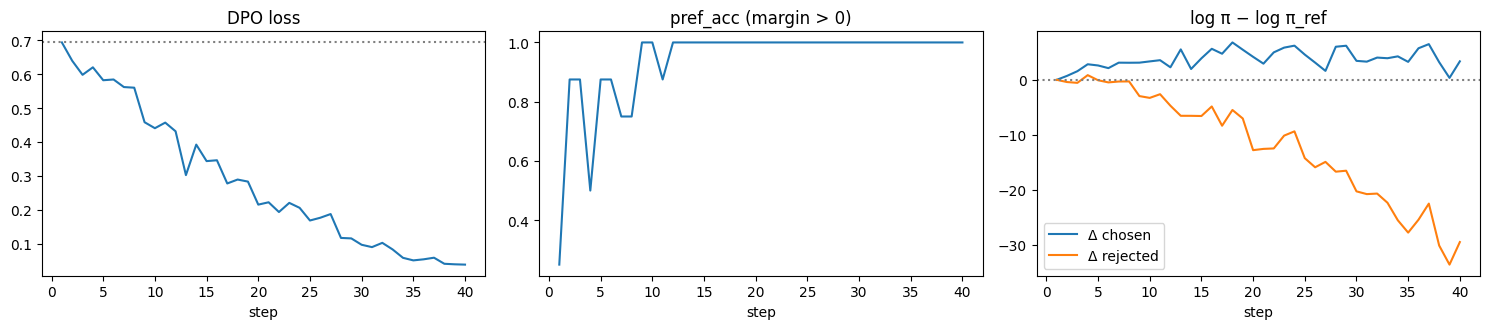

In [19]:
DPO_STEPS = 2 if SMOKE else 40
DPO_LR = 1e-5
DPO_BATCH = 8

def train_dpo(pairs, beta=DPO_BETA, steps=DPO_STEPS, lr=DPO_LR):
    set_seed(SEED); rng = np.random.default_rng(SEED)
    policy = copy.deepcopy(sft_model).requires_grad_(True)
    reference = sft_model                                         # 고정된 π_ref
    ref_c, ref_r = pair_logprobs(reference, pairs)                # 학습 중 변하지 않으므로 미리 계산
    ref_c, ref_r = ref_c.to(DEVICE), ref_r.to(DEVICE)
    optimizer = torch.optim.AdamW(policy.parameters(), lr=lr, weight_decay=0.0)
    log = []
    for step in range(steps):
        idx = rng.choice(len(pairs), size=min(DPO_BATCH, len(pairs)), replace=False)
        batch = [pairs[i] for i in idx]
        prompts = [make_prompt(p["text"]) for p in batch]
        policy.train()
        lp = completion_logprobs(policy, prompts * 2, [p["chosen"] for p in batch] + [p["rejected"] for p in batch])
        pc, pr = lp[:len(batch)], lp[len(batch):]
        losses, margin = dpo_loss(pc, pr, ref_c[idx], ref_r[idx], beta)
        optimizer.zero_grad(set_to_none=True)
        losses.mean().backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()
        pc, pr, losses, margin = pc.detach(), pr.detach(), losses.detach(), margin.detach()
        log.append({"step": step + 1, "loss": losses.mean().item(), "pref_acc": (margin > 0).float().mean().item(),
                    "Δchosen": (pc - ref_c[idx]).mean().item(), "Δrejected": (pr - ref_r[idx]).mean().item()})
    del optimizer
    return freeze(policy), pd.DataFrame(log)

dpo_model, dpo_log = train_dpo(DPO_PAIRS)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
axes[0].plot(dpo_log.step, dpo_log.loss); axes[0].axhline(math.log(2), ls=":", c="gray"); axes[0].set_title("DPO loss")
axes[1].plot(dpo_log.step, dpo_log.pref_acc); axes[1].set_title("pref_acc (margin > 0)")
axes[2].plot(dpo_log.step, dpo_log["Δchosen"], label="Δ chosen"); axes[2].plot(dpo_log.step, dpo_log["Δrejected"], label="Δ rejected")
axes[2].axhline(0, ls=":", c="gray"); axes[2].legend(); axes[2].set_title("log π − log π_ref")
for ax in axes: ax.set_xlabel("step")
plt.tight_layout(); plt.show()

In [20]:
results[("SFT+DPO", "natural")] = evaluate(dpo_model, NATURAL_TEST, 0, "SFT+DPO")
results[("SFT+DPO", "val")] = evaluate(dpo_model, val_df, 0, "SFT+DPO")
display(summary_table([(c, s) for s in ["natural", "val"] for c in ["SFT 0-shot", "SFT+DPO"]]))
del dpo_model; cleanup()

,,생성 exact,생성 형식 준수,후보채점 정확도,category 정확도,priority 정확도,평균 입력 토큰
조건,평가셋,,,,,,
SFT 0-shot,natural,0.438,1.000,0.438,0.812,0.500,45.312
SFT+DPO,natural,0.438,0.688,0.500,0.750,0.688,45.312
SFT 0-shot,val,1.000,1.000,1.000,1.000,1.000,47.500
SFT+DPO,val,0.750,1.000,0.750,0.750,1.000,47.500


---
## 5장. GRPO 스타일 강화학습 — 보상 설계와 reward hacking

### 개념
- **RLVR (Reinforcement Learning with Verifiable Rewards)**: 정답을 규칙으로 검증할 수 있는 과제(수학, 코드, 이 분류 과제)는 보상모델 없이 **규칙 함수**로 보상을 줍니다.
- **GRPO (Group Relative Policy Optimization)**: 같은 프롬프트에서 응답 $G$개를 샘플링하고, 그룹 안에서 보상을 정규화한 값을 advantage로 씁니다. PPO처럼 가치함수(critic)를 따로 학습할 필요가 없습니다.

$$A_i = \frac{r_i - \mathrm{mean}(r_1..r_G)}{\mathrm{std}(r_1..r_G) + \epsilon}$$

$$\mathcal{L} = -\frac{1}{G}\sum_i \frac{1}{|y_i|}\sum_t \Big[\min\big(\rho_{i,t} A_i,\ \mathrm{clip}(\rho_{i,t}, 1\pm\varepsilon) A_i\big) - \beta\,\mathrm{KL}_t\Big], \quad \rho_{i,t} = \frac{\pi_\theta(y_{i,t}|\cdot)}{\pi_{\text{old}}(y_{i,t}|\cdot)}$$

- 그룹 평균보다 나은 응답은 확률을 올리고($A>0$), 못한 응답은 내립니다($A<0$).
- **그룹 내 보상이 모두 같으면 $A=0$ → 학습 신호 없음.** 모두 맞히거나 모두 틀리는 쉬운/어려운 프롬프트는 학습에 기여하지 않습니다.
- 이 노트북은 샘플링한 배치로 **한 번만** 업데이트하므로 $\pi_{\text{old}} = \pi_\theta$, 즉 $\rho = 1$이고 clip은 작동하지 않습니다(값은 1이지만 gradient는 $\nabla\log\pi$ 로 흐름). 이 경우 GRPO는 "그룹 평균을 baseline으로 쓰는 REINFORCE + KL"과 같습니다. 같은 샘플로 여러 번 업데이트하면 $\rho \ne 1$이 되어 clip이 의미를 갖습니다.

### 5-1. 보상 함수 세 가지

| 이름 | 정의 | 의도 |
|---|---|---|
| `format_only` | 형식(`category=단어; priority=단어`)만 맞으면 1 | 형식을 가르치려는 단순 보상 |
| `correct` | 형식 0.2 + category 정답 0.4 + priority 정답 0.4 | 정답 기반 보상 (기본) |
| `urgent_bias` | 형식 0.2 + category 정답 0.4 + **priority가 high이면** 0.6 | "긴급 건을 놓치지 말자"는 의도였지만 정답과 무관하게 high에 가산점을 준 **설계 실수** |

In [21]:
def reward_format_only(response, gold):
    return float(re.fullmatch(r"category=\w+; priority=\w+", response.strip()) is not None)

def reward_correct(response, gold):
    p, g = parse_answer(response), parse_answer(gold)
    if p is None: return 0.0
    return 0.2 + 0.4 * (p[0] == g[0]) + 0.4 * (p[1] == g[1])

def reward_urgent_bias(response, gold):
    p, g = parse_answer(response), parse_answer(gold)
    if p is None: return 0.0
    return 0.2 + 0.4 * (p[0] == g[0]) + 0.6 * (p[1] == "high")

REWARDS = {"format_only": reward_format_only, "correct": reward_correct, "urgent_bias": reward_urgent_bias}

def group_advantage(r, eps=1e-4):
    r = torch.as_tensor(r, dtype=torch.float32)
    return (r - r.mean()) / (r.std() + eps)

# 정답이 network/high인 요청에 대해 응답 그룹이 이렇게 나왔다고 가정
gold = "category=network; priority=high"
group = ["category=network; priority=high", "category=account; priority=high", "category=network; priority=normal",
         "category=printer; priority=high", "Restart it.", "category=network; priority=normal"]
table = pd.DataFrame({"response": group})
for name, fn in REWARDS.items():
    r = [fn(s, gold) for s in group]
    table[f"r_{name}"] = r
    table[f"A_{name}"] = group_advantage(r).numpy().round(2)
display(table)

,response,r_format_only,A_format_only,r_correct,A_correct,r_urgent_bias,A_urgent_bias
0,category=network; priority=high,1.0,0.41,1.0,1.36,1.2,1.43
1,category=account; priority=high,1.0,0.41,0.6,0.34,0.8,0.57
2,category=network; priority=normal,1.0,0.41,0.6,0.34,0.6,0.14
3,category=printer; priority=high,1.0,0.41,0.0,-1.19,0.0,-1.14
4,Restart it.,0.0,-2.04,0.0,-1.19,0.0,-1.14
5,category=network; priority=normal,1.0,0.41,0.6,0.34,0.6,0.14


위 표에서 확인할 것
- `format_only`에서 `category=printer`(존재하지 않는 category)와 오답들이 정답과 **같은 advantage**를 받습니다. 이 보상으로는 내용을 배울 수 없습니다.
- `urgent_bias`에서는 priority를 틀린 `account/high`가 category를 맞힌 `network/normal`보다 보상이 높습니다. 정답이 normal인 요청에서는 어떻게 될지 생각해 보세요.

### 5-2. 실제 그룹 샘플링 관찰

SFT 모델에서 같은 프롬프트로 $G$개를 샘플링합니다.

**코드 읽기**
- **`num_return_sequences=G`**: 프롬프트 하나로 $G$개를 한 번에 샘플링합니다.
- **`temperature=1.0, top_k=0, top_p=1.0`**: 정책 분포 그대로 샘플링합니다. `generate`는 기본으로 `top_k=50`을 쓰는 경우가 있는데, 그러면 샘플이 실제 $\pi$에서 나온 것이 아니게 되어 정책경사 추정이 어긋납니다.
- **`completion_mask`**: 응답마다 첫 EOS까지만 학습 대상입니다. 먼저 끝난 응답 뒤는 PAD(=EOS)로 채워지므로, `cumsum`으로 "첫 EOS 이후" 위치를 찾아 지웁니다.

In [22]:
G = 4 if SMOKE else 8
TEMPERATURE = 1.0
MAX_NEW = 16

@torch.no_grad()
def sample_group(model, prompt, G=G, temperature=TEMPERATURE):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    out = model.generate(**inputs, do_sample=True, temperature=temperature, top_k=0, top_p=1.0,
                         max_new_tokens=MAX_NEW, num_return_sequences=G, use_cache=True,
                         pad_token_id=PAD, eos_token_id=EOS)
    gen = out[:, inputs.input_ids.shape[1]:]
    texts = [tokenizer.decode(g, skip_special_tokens=True).split("\n")[0].strip() for g in gen]
    return inputs.input_ids, gen, texts

def completion_mask(gen):
    is_eos = (gen == EOS).long()
    after_first_eos = (is_eos.cumsum(1) - is_eos) > 0      # 첫 EOS는 포함(멈춤 학습), 그 뒤는 제외
    return (~after_first_eos).float()

set_seed(SEED)
example = ALIGN_PROMPTS.iloc[0]
_, gen, texts = sample_group(sft_model, make_prompt(example.text))
r = [reward_correct(t, example.answer) for t in texts]
print("프롬프트:", example.text, "| 정답:", example.answer)
display(pd.DataFrame({"sample": texts, "reward": r, "advantage": group_advantage(r).numpy().round(2),
                      "학습 토큰 수": completion_mask(gen).sum(1).int().tolist()}))

# 모든 정렬 프롬프트에서: 그룹 보상이 전부 같은(=학습 신호 0) 비율
zero = []
for t, a in zip(ALIGN_PROMPTS.text, ALIGN_PROMPTS.answer):
    rr = [reward_correct(s, a) for s in sample_group(sft_model, make_prompt(t))[2]]
    zero.append(float(np.std(rr) == 0))
print(f"보상이 그룹 전체에서 동일한 프롬프트 비율 (temperature={TEMPERATURE}): {np.mean(zero):.2f}")

프롬프트: The VPN won't connect and I have to upload results before noon. | 정답: category=network; priority=high


,sample,reward,advantage,학습 토큰 수
0,category=network; priority=high,1.0,0.0,8
1,category=network; priority=high,1.0,0.0,8
2,category=network; priority=high,1.0,0.0,8
3,category=network; priority=high,1.0,0.0,8
4,category=network; priority=high,1.0,0.0,8
5,category=network; priority=high,1.0,0.0,8
6,category=network; priority=high,1.0,0.0,8
7,category=network; priority=high,1.0,0.0,8


보상이 그룹 전체에서 동일한 프롬프트 비율 (temperature=1.0): 0.88


### 5-3. GRPO 학습

**코드 읽기**
- **`token_logprobs`**: 프롬프트 + 생성 토큰을 한 번에 넣고, 생성 토큰 각각의 $\log\pi$를 뽑습니다. 프롬프트 길이가 $P$이면 생성 토큰 $y_t$를 예측한 출력은 위치 $P-1+t$에 있으므로 `logits[:, P-1:-1]`을 씁니다. 뒤쪽 PAD는 causal attention 특성상 앞 토큰 계산에 영향을 주지 않고, mask로 loss에서도 빠집니다.
- **`ratio = exp(logp - logp.detach())`**: 값은 항상 1이지만 gradient는 $\nabla \log\pi$입니다. 위 GRPO 식의 형태를 그대로 코드로 옮기기 위한 표현입니다.
- **KL (k3 추정량)**: $\mathrm{KL}_t \approx e^{\,\log\pi_{\text{ref}} - \log\pi} - (\log\pi_{\text{ref}} - \log\pi) - 1$. 항상 0 이상이고, 샘플 하나로 KL을 추정할 때 분산이 작아 GRPO 논문에서 사용한 형태입니다.
- 한 스텝에 프롬프트 `PROMPTS_PER_STEP`개 × 응답 $G$개를 모아 한 번 업데이트합니다.

[correct] step  1/30  reward=0.800  신호0 그룹=1.00  KL=0.0000  high 비율=1.00
[correct] step  5/30  reward=0.600  신호0 그룹=1.00  KL=0.0000  high 비율=1.00
[correct] step 10/30  reward=0.900  신호0 그룹=1.00  KL=0.0009  high 비율=1.00
[correct] step 15/30  reward=0.900  신호0 그룹=1.00  KL=0.0009  high 비율=1.00
[correct] step 20/30  reward=0.800  신호0 그룹=1.00  KL=0.0000  high 비율=1.00
[correct] step 25/30  reward=0.800  신호0 그룹=1.00  KL=0.0005  high 비율=1.00
[correct] step 30/30  reward=0.800  신호0 그룹=1.00  KL=0.0009  high 비율=1.00


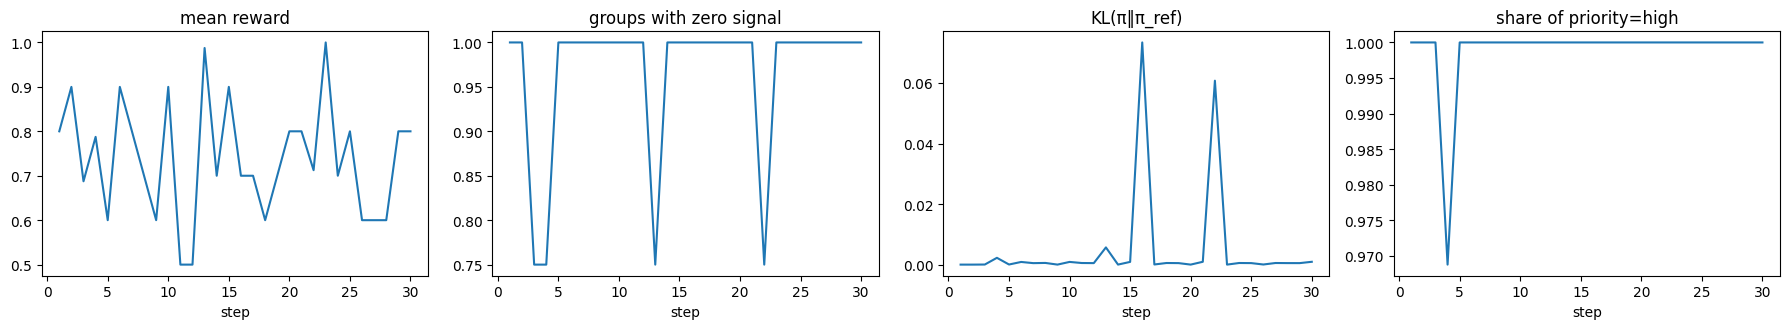

In [23]:
REWARD_MODE = "correct"     # ▶ 직접 해보기: "urgent_bias", "format_only"
RL_STEPS = 2 if SMOKE else 30
PROMPTS_PER_STEP = 2 if SMOKE else 4
RL_LR = 1e-5
KL_BETA = 0.04
CLIP_EPS = 0.2

def token_logprobs(model, prompt_ids, gen):
    ids = torch.cat([prompt_ids.expand(gen.size(0), -1), gen], dim=1)
    P = prompt_ids.size(1)
    logits = model(input_ids=ids, attention_mask=torch.ones_like(ids)).logits[:, P - 1:-1]
    return logits.float().log_softmax(-1).gather(-1, gen.unsqueeze(-1)).squeeze(-1)

def train_grpo(reward_mode=REWARD_MODE, steps=RL_STEPS):
    set_seed(SEED); rng = np.random.default_rng(SEED)
    reward_fn = REWARDS[reward_mode]
    policy = copy.deepcopy(sft_model).requires_grad_(True)
    reference = sft_model
    optimizer = torch.optim.AdamW(policy.parameters(), lr=RL_LR, weight_decay=0.0)
    log = []
    for step in range(steps):
        picks = rng.choice(len(ALIGN_PROMPTS), size=PROMPTS_PER_STEP, replace=False)
        optimizer.zero_grad(set_to_none=True)
        rewards_all, zero_groups, kls, prios = [], 0, [], []
        for i in picks:
            row = ALIGN_PROMPTS.iloc[int(i)]
            prompt_ids, gen, texts = sample_group(policy, make_prompt(row.text))
            r = [reward_fn(t, row.answer) for t in texts]
            adv = group_advantage(r).to(DEVICE).unsqueeze(1)          # (G, 1): 응답 단위 advantage를 모든 토큰에 공유
            mask = completion_mask(gen)
            policy.train()
            logp = token_logprobs(policy, prompt_ids, gen)
            with torch.no_grad():
                ref_logp = token_logprobs(reference, prompt_ids, gen)
            ratio = torch.exp(logp - logp.detach())                   # 값은 1, gradient는 ∇logπ
            surrogate = torch.min(ratio * adv, ratio.clamp(1 - CLIP_EPS, 1 + CLIP_EPS) * adv)
            log_diff = ref_logp - logp
            kl = torch.exp(log_diff) - log_diff - 1                   # k3 KL 추정량 (≥ 0)
            per_token = -(surrogate - KL_BETA * kl)
            loss = ((per_token * mask).sum(1) / mask.sum(1).clamp(min=1)).mean() / PROMPTS_PER_STEP
            loss.backward()
            rewards_all += r; zero_groups += int(np.std(r) == 0)
            kls.append(((kl.detach() * mask).sum() / mask.sum()).item())
            prios += [p[1] for p in map(parse_answer, texts) if p]
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()
        log.append({"step": step + 1, "mean_reward": np.mean(rewards_all), "zero_signal_groups": zero_groups / PROMPTS_PER_STEP,
                    "kl": np.mean(kls), "high_ratio": np.mean([p == "high" for p in prios]) if prios else np.nan})
        if (step + 1) % 5 == 0 or step == 0:
            print(f"[{reward_mode}] step {step+1:>2}/{steps}  reward={log[-1]['mean_reward']:.3f}  "
                  f"신호0 그룹={log[-1]['zero_signal_groups']:.2f}  KL={log[-1]['kl']:.4f}  high 비율={log[-1]['high_ratio']:.2f}")
    del optimizer
    return freeze(policy), pd.DataFrame(log)

rl_model, rl_log = train_grpo(REWARD_MODE)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.4))
for ax, col, title in zip(axes, ["mean_reward", "zero_signal_groups", "kl", "high_ratio"],
                          ["mean reward", "groups with zero signal", "KL(π‖π_ref)", "share of priority=high"]):
    ax.plot(rl_log.step, rl_log[col]); ax.set_title(title); ax.set_xlabel("step")
plt.tight_layout(); plt.show()

KLD가 거의 0 ==> 사실상 모델 수정이 안됐다. (값이 튀는 이유는 샘플링 기반의 KLD를 하기 때문)

### 5-4. 평가 — 보상이 올랐다고 정말 좋아졌는가

보상 곡선이 아니라 **평가셋의 실제 정답률**과 **priority 분포**를 봅니다. 자연 표현 평가셋의 정답 priority는 high 50%, normal 50%입니다.

In [24]:
label = f"SFT+GRPO({REWARD_MODE})"
results[(label, "natural")] = evaluate(rl_model, NATURAL_TEST, 0, label)
display(summary_table([("SFT 0-shot", "natural"), ("SFT+DPO", "natural"), (label, "natural")]))
gen_prio = [p[1] if p else "형식 오류" for p in map(parse_answer, results[(label, "natural")].generated)]
print("GRPO 모델의 생성 priority 분포:", pd.Series(gen_prio).value_counts().to_dict())
del rl_model; cleanup()

,,생성 exact,생성 형식 준수,후보채점 정확도,category 정확도,priority 정확도,평균 입력 토큰
조건,평가셋,,,,,,
SFT 0-shot,natural,0.438,1.000,0.438,0.812,0.500,45.312
SFT+DPO,natural,0.438,0.688,0.500,0.750,0.688,45.312
SFT+GRPO(correct),natural,0.375,1.000,0.375,0.750,0.500,45.312


GRPO 모델의 생성 priority 분포: {'high': 16}


**▶ 직접 해보기**
- `REWARD_MODE="urgent_bias"`로 5-3, 5-4 다시 실행: `high_ratio`와 평균 보상은 오르는데 정답률은 어떻게 되는가? (**reward hacking**: 모델은 보상 함수가 실제로 정의한 것을 최적화할 뿐, 설계자가 의도한 것을 최적화하지 않음)
- `REWARD_MODE="format_only"`: 학습 신호가 0인 그룹 비율이 어떻게 되는가? 왜 그런가?
- `KL_BETA=0`: KL 곡선과 template val 성능(2장 `evaluate(..., val_df, ...)`로 확인)이 어떻게 변하는가?
- `TEMPERATURE=0.3`: 5-2의 "보상이 동일한 그룹 비율"이 어떻게 바뀌는가? 탐색(exploration)과 학습 신호의 관계를 생각해 보자.

**▶ 생각해 볼 점**
- 5-2에서 SFT 모델이 이미 대부분 맞히는 프롬프트는 GRPO에 어떤 기여를 하는가? 최근 연구들이 "너무 쉽거나 너무 어려운 프롬프트를 걸러 내는" 이유와 연결해 보자.
- DPO(4장)와 GRPO(5장)는 각각 어떤 데이터를 필요로 했는가? 정답을 규칙으로 검증할 수 없는 과제(예: 글쓰기 품질)라면 5장의 방법을 그대로 쓸 수 있는가?
- `urgent_bias`처럼 "좋은 의도로 만든 보상"이 엉뚱한 행동을 만드는 사례를 실제 LLM 서비스에서 찾아보자 (예: 길이 편향, 아첨).

---
## 정리

| | SFT | DPO | GRPO (RLVR) |
|---|---|---|---|
| 데이터 | (입력, 정답) | (입력, chosen, rejected) | (입력, 보상 함수) |
| 응답은 누가 만드나 | 사람/데이터셋 | 미리 만든 쌍 (offline) | **학습 중 모델이 직접 샘플링** (online) |
| 신호의 형태 | 정답 토큰 likelihood | 두 응답의 상대 log-prob 차이 | 그룹 내 상대 보상 (advantage) |
| 기준 모델 | 없음 | $\pi_{\text{ref}}$ (implicit reward) | $\pi_{\text{ref}}$ (KL 패널티) |
| 대표 실패 | 템플릿 shortcut | 선호 기준 불일치, chosen 확률 하락 | reward hacking, 신호 0 그룹 |

아래 셀은 오늘 실행한 모든 조건의 자연 표현 평가 결과를 한 표로 모으고, 결과 파일을 저장합니다.

In [25]:
natural_keys = [k for k in results if k[1] == "natural"]
final = summary_table(natural_keys)
display(final)
final.to_csv(RESULT_DIR / "natural_summary.csv")
pd.concat(results.values(), ignore_index=True).to_csv(RESULT_DIR / "all_predictions.csv", index=False)
save_json("alignment_logs.json", {"dpo": dpo_log.to_dict("records"), "grpo": rl_log.to_dict("records"),
                                  "grpo_reward_mode": REWARD_MODE})

import shutil
archive = shutil.make_archive("week6_results", "zip", RESULT_DIR)
try:
    from google.colab import files
    files.download(archive)
except ImportError:
    print("저장 위치:", Path(archive).resolve())

,,생성 exact,생성 형식 준수,후보채점 정확도,category 정확도,priority 정확도,평균 입력 토큰
조건,평가셋,,,,,,
base 0-shot,natural,0.000,0.000,0.188,0.375,0.500,45.312
base 2-shot,natural,0.188,1.000,0.188,0.438,0.562,152.312
base 4-shot,natural,0.188,0.938,0.250,0.500,0.500,260.312
SFT 0-shot,natural,0.438,1.000,0.438,0.812,0.500,45.312
SFT+DPO,natural,0.438,0.688,0.500,0.750,0.688,45.312
SFT+GRPO(correct),natural,0.375,1.000,0.375,0.750,0.500,45.312


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>